# Retail Sales Analysis and Business Insights using Python
## Introduction
    
## This project analyzes a large Indian retail sales dataset to understand business performance, sales trends, and customer behavior. Using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn, the dataset is cleaned, analyzed, and visualized to generate meaningful business insights.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Patel Happy\OneDrive\Documents\HAPPY AI_ML\Project\Indian_Retail_Sales_Dataset.csv")

print("\nDataset Shape:", df.shape)

display(df.head())
display(df.tail())


Dataset Shape: (52000, 10)


,Order_id,Order_date,Region,City,Customer_type,Product_category,Quantity,Unit_price,Discount_Percentage,Revenue
0,1,2023-01-02,West,Surat,Member,Clothing,2,2800,29,4788
1,2,2023-01-03,South,Bangalore,Regular,Home & Kitchen,3,4550,27,12422
2,3,2023-01-04,East,Patna,Member,Electronics,1,4800,29,3408
3,4,2023-01-05,Central,Bhopal,Regular,Home & Kitchen,5,3500,9,17185
4,5,2023-01-06,North,Jaipur,Member,Home & Kitchen,3,4200,8,12264


,Order_id,Order_date,Region,City,Customer_type,Product_category,Quantity,Unit_price,Discount_Percentage,Revenue
51995,51996,2023-06-16,West,Mumbai,Regular,Electronics,5,8400,11,41076
51996,51997,2023-06-17,South,Chennai,Member,Electronics,5,7800,25,37050
51997,51998,2023-06-18,East,Kolkata,Regular,Sports,2,1200,26,2088
51998,51999,2023-06-19,Central,Indore,Member,Beauty,1,1000,6,940
51999,52000,2023-06-20,North,Jaipur,Regular,Home & Kitchen,4,4200,6,16548


# Data Cleaning & EDA

In [3]:
# Check Missing Values

df.isnull().sum()

Order_id               0
Order_date             0
Region                 0
City                   0
Customer_type          0
Product_category       0
Quantity               0
Unit_price             0
Discount_Percentage    0
Revenue                0
dtype: int64

In [4]:
# Data Types

df.dtypes

Order_id                int64
Order_date             object
Region                 object
City                   object
Customer_type          object
Product_category       object
Quantity                int64
Unit_price              int64
Discount_Percentage     int64
Revenue                 int64
dtype: object

In [5]:
# Duplicates

df.duplicated().sum()

np.int64(0)

In [6]:
# Summary Statistics

df.describe()

,Order_id,Quantity,Unit_price,Discount_Percentage,Revenue
count,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000
mean,26000.500000,2.999058,3813.235577,17.494192,10769.962712
std,15011.251336,1.405682,2375.653561,7.518985,9224.125201
min,1.000000,1.000000,400.000000,5.000000,280.000000
25%,13000.750000,2.000000,1950.000000,11.000000,3760.000000
50%,26000.500000,3.000000,3500.000000,18.000000,7760.000000
75%,39000.250000,4.000000,4900.000000,24.000000,14664.000000
max,52000.000000,5.000000,8400.000000,30.000000,41580.000000


In [14]:
df["Order_date"] = pd.to_datetime(df["Order_date"])
df["Month"] = df["Order_date"].dt.month

df.dtypes

Order_id                        int64
Order_date             datetime64[ns]
Region                         object
City                           object
Customer_type                  object
Product_category               object
Quantity                        int64
Unit_price                      int64
Discount_Percentage             int64
Revenue                         int64
Month                           int32
dtype: object

# Business Analysis

In [5]:
# Region wise Revenue

df.pivot_table(index="Region", values="Revenue", aggfunc="sum")

,Revenue
Region,
Central,97411520
East,78623172
North,118276512
South,126955483
West,138771374


In [11]:
# Category Wise Sales performance

df.pivot_table(index="Product_category", values="Quantity", aggfunc="sum")

,Quantity
Product_category,
Beauty,12165
Clothing,31276
Electronics,46537
Grocery,10843
Home & Kitchen,39698
Sports,15432


In [12]:
# Customer Type Comparison

df.pivot_table(index="Customer_type", values="Revenue", aggfunc="sum")

,Revenue
Customer_type,
Member,281268957
Regular,278769104


In [15]:
# Monthly Sales Trend

df.pivot_table(index="Month", values="Revenue", aggfunc="sum")

,Revenue
Month,
1,48197458
2,44142679
3,47798550
4,45568373
5,47913877
6,46303700
7,47127173
8,47750809
9,45549024


## Top Cities Analysis

In [22]:
# Top 5 Cities by Revenue

df.pivot_table(index="City", values="Revenue", aggfunc="sum").sort_values(by="Revenue",ascending=False).head()

,Revenue
City,
Mumbai,69796111
Surat,68975263
Bangalore,64566842
Chennai,62388641
Delhi,59472000


# Data Visualization

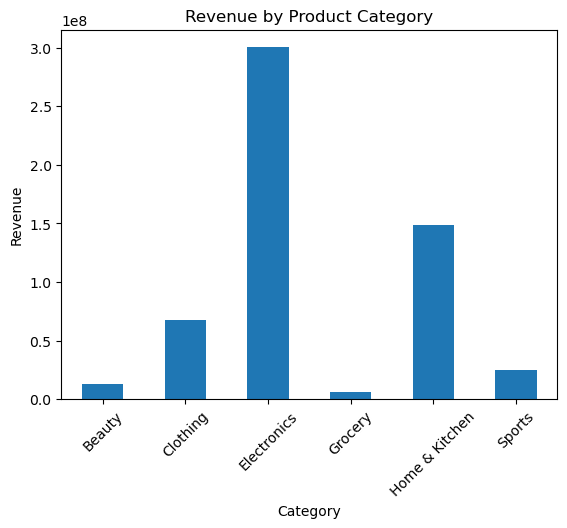

In [14]:
df.groupby('Product_category')['Revenue'].sum().plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

## The bar chart shows revenue generated by each product category. From the chart, it is clear that Electronics categories have the highest revenue among all product categories. Grocery generates the lowest revenue among all categories.
## This indicates that the Electronics has the best sales performance and the Grocery needs improvement in sales and marketing strategies.

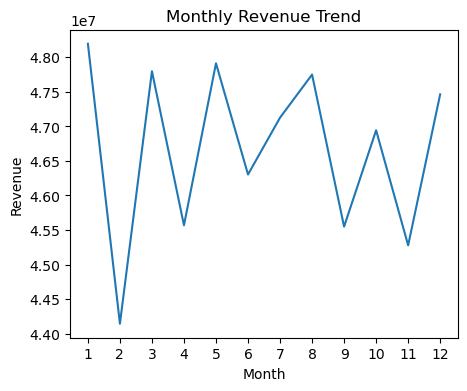

In [15]:
plt.figure(figsize=(5,4))
df.groupby("Month")["Revenue"].sum().plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(range(1,13))
plt.show()

## The line chart shows the monthly revenue trend. The chart shows that revenue fluctuates throughout the year, but overall it remains stable. The highest revenue is seen in months 1, 5, and 8, while the lowest is in month 2. This indicates that the business is performing well, but lacks consistency. In the future, the company should focus on improving low-performing months and maintaining high performance.

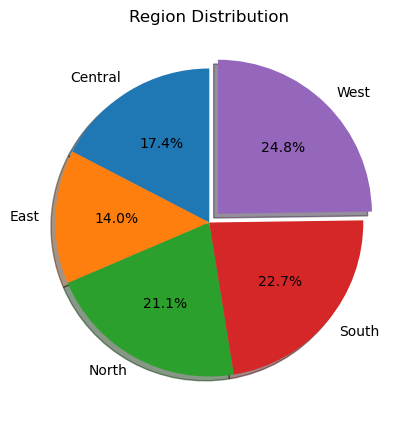

In [16]:
reg = df.groupby("Region")["Revenue"].sum()
plt.figure(figsize=(5,5))
plt.pie(reg, labels=reg.index,explode=(0, 0, 0, 0, 0.08),startangle = 90,shadow=True, autopct="%1.1f%%")
plt.title("Region Distribution")
plt.show()

## The pie chart shows the percentage distribution of different region in the dataset. The chart shows that the West region has the highest share compared to others. The East region generates the lowest revenue among all regions.
## This means most of the business comes from the West and South regions.

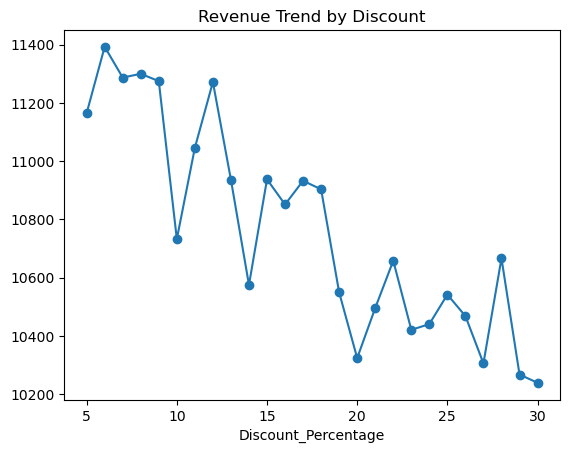

In [17]:
df.groupby("Discount_Percentage")["Revenue"].mean().plot(kind='line', marker='o')
plt.title('Revenue Trend by Discount')
plt.show()

## There is a negative relationship between the discount and the revenue. As the discount percentage increases, the total revenue consistently drops. Giving higher discounts in this scenario is actually reducing your total money earned rather than helping it

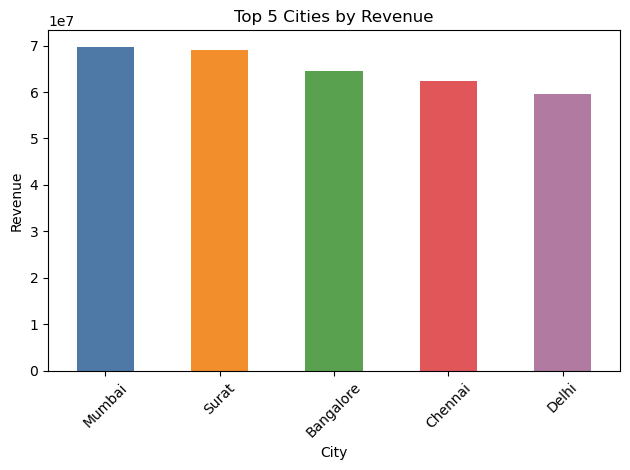

In [18]:
top_city = df.groupby("City")["Revenue"].sum().sort_values(ascending=False).head()
top_city.plot(kind="bar",color = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1'])
plt.title("Top 5 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## The chart shows that Mumbai generates the highest revenue, followed closely by Surat and Bangalore, while Delhi has the lowest revenue.

# Business Recommendations :-
## 1.Businesses should focus more on high-performing categories like Electronics and Home & Kitchen to maximize revenue.
## 2.Focus on improving low-performing cities while maintaining strong performance in top cities.
## 3.Pricing strategies should be optimized to maximize revenue while maintaining customer satisfaction.
## 4.Focus on Consistency

# Conclusion

## Electronics and Home & Kitchen categories generate strong sales performance.
## West and South regions contribute the highest revenue.
## Major cities like Mumbai and Surat play an important role in total sales.
## Monthly sales trends show sales are stable but not perfectly consistent.
## Discounts have a slight negative correlation with revenue.